In [460]:
from pathlib import Path

import mlflow
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torchsummary
from matplotlib import pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from tqdm import tqdm_notebook

%matplotlib inline

import warnings

warnings.filterwarnings(action="ignore", category=DeprecationWarning)

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print("CUDA is not available.  Training on CPU ...")
else:
    print("CUDA is available!  Training on GPU ...")

CUDA is available!  Training on GPU ...


#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [461]:
!python --version
from importlib.metadata import version

for b in ["torch", "torchvision", "tqdm", "matplotlib", "seaborn", "Pillow"]:
    print(b + " version: " + version(b))

Python 3.12.3
torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.8
seaborn version: 0.13.2
Pillow version: 12.1.1


Сверим с версиями питона и библиотек, на которых работал эталонный ноутбук:

- Python 3.12.12
- torch version: 2.8.0+cu126
- torchvision version: 0.23.0+cu126
- tqdm version: 4.67.1
- matplotlib version: 3.10.0
- seaborn version: 0.13.2
- Pillow version: 11.3.0


In [462]:
# разные режимы датасета
DATA_MODES = ["train", "val", "test"]

# работаем на видеокарте
DEVICE = torch.device("cuda")

# определим директории с тренировочными и тестовыми файлами
TEST_DIR = Path("/home/andrew/worka/DeepLearning/5_homework/testset")  # Path('./data/train/')
TRAIN_DIR = Path("/home/andrew/worka/DeepLearning/5_homework/train/")  # Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [463]:
#!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

In [464]:
#!unzip -q 5_homework/journey-springfield.zip

Посмотрите на структуру файлов в папках train и testset.

В train лежат данные, которые мы будем использовать для обучения модели. Изображения персонажей разложены по папкам, которые названы по именам персонажей. Названия папок мы в дальнейшем будет использовать в качестве текстовых меток классов.

В testset находятся изображения, для которых вам надо будет сделать прогноз наиболее вероятного класса.


Для обращения к файлам сформируем списки имен файлов обучающей+валидационнной и тестовой выборок. Это полные имена, включающие путь к файлам.


In [465]:
train_val_files = sorted(list(TRAIN_DIR.rglob("*.jpg")))
test_files = sorted(list(TEST_DIR.rglob("*.jpg")))

Кодировать имена персонажей в числовые метки класса и обратно будем при помощи `LabelEncoder`.

Для train выборки сформируем список текстовых меток всех изображений - имя родительской директории, которая одновременно является и именем персонажа. Зададим числовые метки классов нашего энкодера при помощи метода `fit`.

Далее будем применять метод `transform` для преобразования текстовых меток в числовые, и метод `inverse_transform` для преобразования числовых меток в текстовые.


In [466]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим train выборку на обучающую и валидационнную части. Для того, чтобы персонажи были пропорционально представлены в обучающей и валидационнной подвыборках, применим стратификацию по меткам класса.

In [467]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    train_val_files, test_size=0.25, stratify=train_val_labels
)

In [468]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return (
            self.len_
        )  # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == "test":
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform(
                [
                    path.parent.name,
                ]
            ).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
        if self.mode == "train":
            transform = v2.Compose(
                [
                    v2.ToImage(),
                    v2.Resize(RESCALE_SIZE),
                    # --------------- Аугментация -------------------
                    v2.RandomHorizontalFlip(p=0.5),
                    v2.RandomRotation(degrees=25),
                    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
                    # v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                    # v2.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
                    # -----------------------------------------------
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ]
            )
        else:
            transform = v2.Compose(
                [
                    v2.ToImage(),
                    v2.Resize(RESCALE_SIZE),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ]
            )

        tensor_transformed = transform(image)
        return tensor_transformed

In [469]:
train_dataset = SimpsonsDataset(train_files, label_encoder=label_encoder, mode="train")
val_dataset = SimpsonsDataset(val_files, label_encoder, mode="val")

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {"train": train_loader, "val": val_loader}

In [470]:
# from torch.utils.data import WeightedRandomSampler

# train_labels = []
# for idx in range(len(train_dataset)):
#     _, label = train_dataset[idx]  # предполагаем, что __getitem__ возвращает (image, label)
#     train_labels.append(label)


# train_labels = np.array(train_labels)

# class_weights_sklearn = compute_class_weight(
#     class_weight='balanced',  # или 'balanced_subsample'
#     classes=np.unique(train_labels),
#     y=train_labels)

# # Вес для КАЖДОГО примера в датасете (не для класса!)
# sample_weights = np.array([class_weights_sklearn[label] for label in train_labels])
# sample_weights = torch.from_numpy(sample_weights).float()

# # Создаём сэмплер
# sampler = WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),  # количество примеров за эпоху
#     replacement=True  # можно брать один пример несколько раз за эпоху
# )

# # Используем в DataLoader (shuffle=False, так как сэмплер уже перемешивает)
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     sampler=sampler,  # вместо shuffle=True
#     num_workers=4
# )

# # val_loader остаётся без изменений
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# loaders = {'train':train_loader, 'val': val_loader}

#### Посмотрим на изображения персонажей

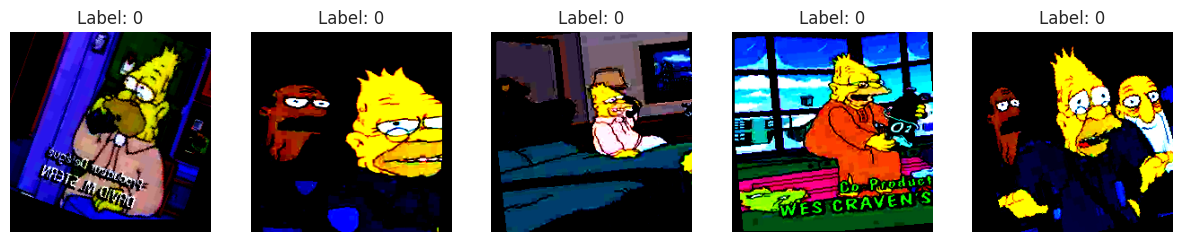

In [471]:
def show_augmentations(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        # денормализация, если нужно
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")
    plt.show()


show_augmentations(train_dataset)

Числовая метка класса: 32
Текстовая метка класса: ['principal_skinner']


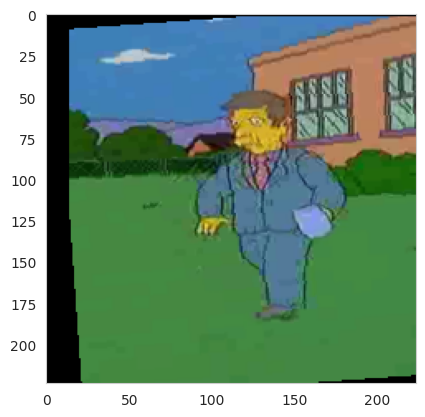

In [472]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)


image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0]])}")
imshow(image_tensor[0])

Давайте посмотрим на наших героев внутри датасета.

In [473]:
def show_images(n_rows, n_cols, dataset):
    # функция выводит изображения в n_rows рядов и n_cols столбцов
    fig, ax = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 4, n_rows * 4),
        sharey=True,
        sharex=True,
    )

    for fig_x in ax.flatten():  # цикл повторяется (n_rows * n_cols) раз
        random_characters = int(
            np.random.uniform(0, len(dataset))
        )  # берем случайное число в диапазоне [0; len(dataset))
        im_val, label = dataset[random_characters]  # получаем изображение (тензорная форма)
        img_label = " ".join(
            map(
                lambda x: x.capitalize(),
                label_encoder.inverse_transform([label])[0].split("_"),
            )
        )  # числовую метку класса преобразуем в текстовую и немного отформатируем
        imshow(
            im_val.data.cpu(), title=img_label, plt_ax=fig_x
        )  # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
        fig_x.set_axis_off()
    return None

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам. Очистка датасета - это один из способов повысить качество модели. Этим можно будет заняться во второй части домашнего задания.

Запустим написанную функцию.

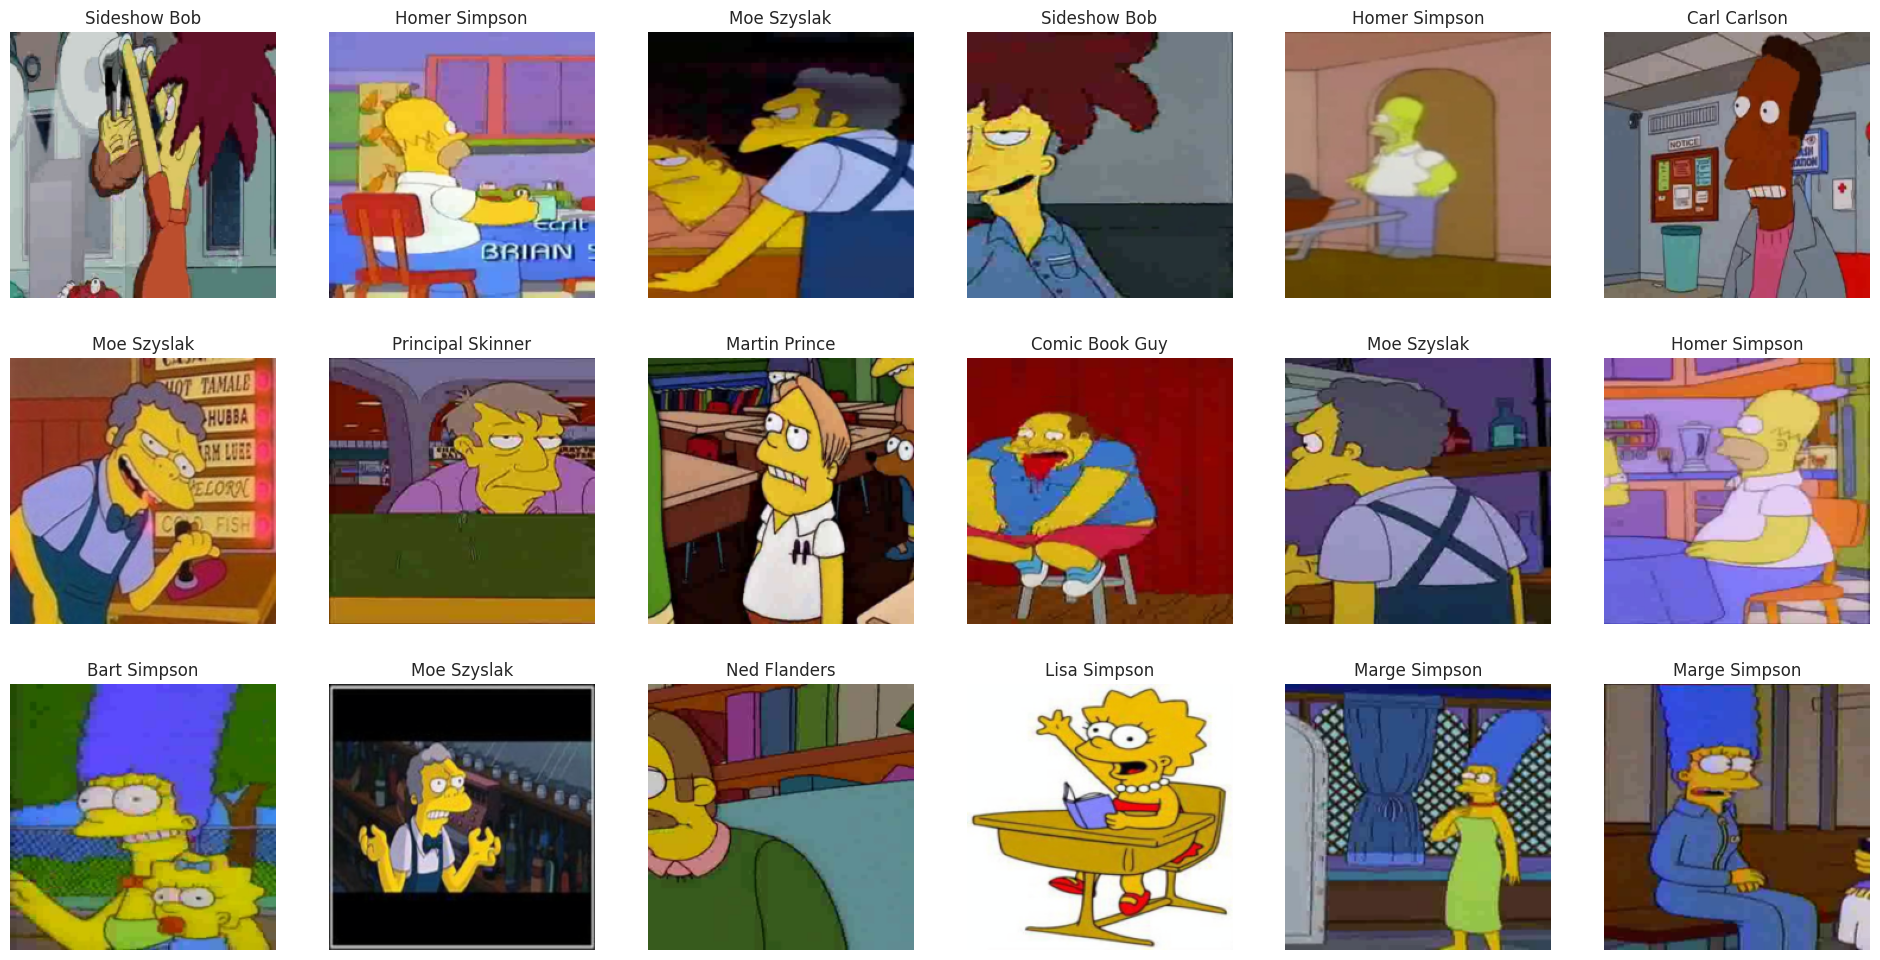

In [474]:
show_images(n_rows=3, n_cols=6, dataset=val_dataset)

## Шаг 3. Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [ ]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.dropout = nn.Dropout(0.2)
        self.out = nn.Linear(96 * 5 * 5, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        x = self.dropout
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [476]:
model_simple_cnn = SimpleCnn(n_classes=len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
       BatchNorm2d-2          [-1, 8, 222, 222]              16
              ReLU-3          [-1, 8, 222, 222]               0
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 16, 109, 109]           1,168
       BatchNorm2d-6         [-1, 16, 109, 109]              32
              ReLU-7         [-1, 16, 109, 109]               0
         MaxPool2d-8           [-1, 16, 54, 54]               0
            Conv2d-9           [-1, 32, 52, 52]           4,640
      BatchNorm2d-10           [-1, 32, 52, 52]              64
             ReLU-11           [-1, 32, 52, 52]               0
        MaxPool2d-12           [-1, 32, 26, 26]               0
           Conv2d-13           [-1, 64, 24, 24]          18,496
      BatchNorm2d-14           [-1, 64,

#### Задание - напишите функции для работы с моделью

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Ниже приводится код для вычисления целевой метрики.

In [477]:
# пример расчета: f1 = f1_score(actual_labels, y_predicted, average='micro')

In [478]:
def calculate_f1_score(preds, targets, num_classes=42, average="macro"):
    """
    Вычисляет F1-score напрямую в PyTorch на GPU

    Args:
        preds: (batch_size,) предсказанные классы
        targets: (batch_size,) истинные классы
        num_classes: количество классов (42 для Симпсонов)
        average: 'macro' или 'weighted'
    """
    # Строим confusion matrix
    confusion_matrix = torch.zeros(num_classes, num_classes, device=preds.device)
    for t, p in zip(targets, preds):
        confusion_matrix[t, p] += 1

    # Вычисляем precision и recall для каждого класса
    tp = torch.diag(confusion_matrix)
    fp = confusion_matrix.sum(dim=0) - tp
    fn = confusion_matrix.sum(dim=1) - tp

    # Precision и recall (избегаем деления на ноль)
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)

    # F1-score для каждого класса
    f1_per_class = 2 * (precision * recall) / (precision + recall + 1e-10)

    if average == "macro":
        return f1_per_class.mean()
    elif average == "weighted":
        # Веса пропорциональны количеству образцов в классе
        class_counts = targets.bincount(minlength=num_classes).float()
        weights = class_counts / class_counts.sum()
        return (f1_per_class * weights).sum()

In [479]:
def fit_by_f1(
    model,
    train_dataloader,
    test_dataloader,
    max_epochs,
    optimizer,
    loss_func,
    num_classes=42,
    augments_used="",
):

    with mlflow.start_run(run_name=f"aug_{augments_used}"):
        mlflow.log_params(
            {
                "max_epochs": max_epochs,
                "batch_size": train_dataloader.batch_size,
                "optimizer": type(optimizer).__name__,
                "loss_func": type(loss_func).__name__,
                "augmentations": augments_used,
                "num_classes": num_classes,
            }
        )

        model.to(DEVICE)
        model.train()

        list_history_train = []

        for it, epoch in enumerate(range(max_epochs)):
            epoch_loss = 0.0
            all_preds = []
            all_targets = []

            for x_batch, y_batch in train_dataloader:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                optimizer.zero_grad()
                outp = model(x_batch)
                loss = loss_func(outp, y_batch)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

                preds = outp.argmax(-1)
                all_preds.append(preds)
                all_targets.append(y_batch)

            # Объединяем все батчи
            all_preds = torch.cat(all_preds)
            all_targets = torch.cat(all_targets)

            # Вычисляем метрики
            accuracy = (all_preds == all_targets).float().mean()
            f1_macro = calculate_f1_score(all_preds, all_targets, num_classes, "macro")
            f1_weighted = calculate_f1_score(all_preds, all_targets, num_classes, "weighted")

            list_history_train.append(
                {
                    "epoch": it + 1,
                    "loss": epoch_loss / len(test_dataloader),
                    "accuracy": accuracy.item(),
                    "f1_macro": f1_macro.item(),
                    "f1_weighted": f1_weighted.item(),
                }
            )

            print(
                f"Epoch - {it + 1}, loss - {loss}, accuracy - {accuracy}, f1_macro - {f1_macro}, f1_weighted - {f1_weighted}"
            )

        model.eval()

        epoch_loss = 0.0
        all_preds_loss = []
        all_targets_loss = []

        for x_batch, y_batch in test_dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            with torch.no_grad():
                outp = model(x_batch)
                loss = loss_func(outp, y_batch)

                epoch_loss += loss.item()

                preds = outp.argmax(-1)
                all_preds_loss.append(preds)
                all_targets_loss.append(y_batch)

        # Объединяем все батчи
        all_preds_loss = torch.cat(all_preds_loss)
        all_targets_loss = torch.cat(all_targets_loss)

        # Вычисляем метрики
        accuracy = (all_preds_loss == all_targets_loss).float().mean()
        f1_macro = calculate_f1_score(all_preds_loss, all_targets_loss, num_classes, "macro")
        f1_weighted = calculate_f1_score(all_preds_loss, all_targets_loss, num_classes, "weighted")

        test_metric = {
            "loss": epoch_loss / len(test_dataloader),
            "accuracy": accuracy.item(),
            "f1_macro": f1_macro.item(),
            "f1_weighted": f1_weighted.item(),
        }

        # После завершения обучения логируем итоговые метрики
        mlflow.log_metrics(
            {
                "final_train_loss": epoch_loss / len(test_dataloader),
                "final_test_accuracy": accuracy.item(),
                "final_test_f1_macro": f1_macro.item(),
            }
        )

        # Логируем саму модель
        mlflow.pytorch.log_model(model, "model")

        return [test_metric, list_history_train]

## Шаг 5. Применение модели к данным

#### Применение модели к данным

Запустите обучение сети

In [480]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr=1e-3)

result = fit_by_f1(
    model=model_simple_cnn,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    max_epochs=10,
    optimizer=optimizer,
    loss_func=criterion,
    augments_used="3f+batchnorm+dropout_10epoch",
)

Epoch - 1, loss - 1.1848645210266113, accuracy - 0.422383576631546, f1_macro - 0.20896190404891968, f1_weighted - 0.40469080209732056
Epoch - 2, loss - 0.4609834849834442, accuracy - 0.6091470718383789, f1_macro - 0.36366212368011475, f1_weighted - 0.5965543389320374
Epoch - 3, loss - 1.1478490829467773, accuracy - 0.6903624534606934, f1_macro - 0.46447810530662537, f1_weighted - 0.6812835931777954
Epoch - 4, loss - 0.5460268259048462, accuracy - 0.7343779802322388, f1_macro - 0.5348740816116333, f1_weighted - 0.7277928590774536
Epoch - 5, loss - 0.5628695487976074, accuracy - 0.7532963752746582, f1_macro - 0.5857605338096619, f1_weighted - 0.7481219172477722
Epoch - 6, loss - 0.5939007997512817, accuracy - 0.7826613187789917, f1_macro - 0.6160844564437866, f1_weighted - 0.7782818078994751
Epoch - 7, loss - 0.419381707906723, accuracy - 0.7974393367767334, f1_macro - 0.6817585229873657, f1_weighted - 0.7942475080490112
Epoch - 8, loss - 0.8815066814422607, accuracy - 0.8083954453468323

2026/04/08 13:35:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/08 13:35:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/08 13:35:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/08 13:35:22 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

In [481]:
result[0]

{'loss': 0.5935423594967622,
 'accuracy': 0.843332052230835,
 'f1_macro': 0.7138479351997375,
 'f1_weighted': 0.8418406248092651}

In [482]:
! uv run mlflow ui --backend-store-uri sqlite:///5_homework/mlflow.db

Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/04/08 13:35:24 ERROR:    [Errno 98] Address already in use


(опционально) Постройте график динамики метрик модели по ходу обучения

In [483]:
import pandas as pd

df = pd.DataFrame(result[1]).set_index("epoch")

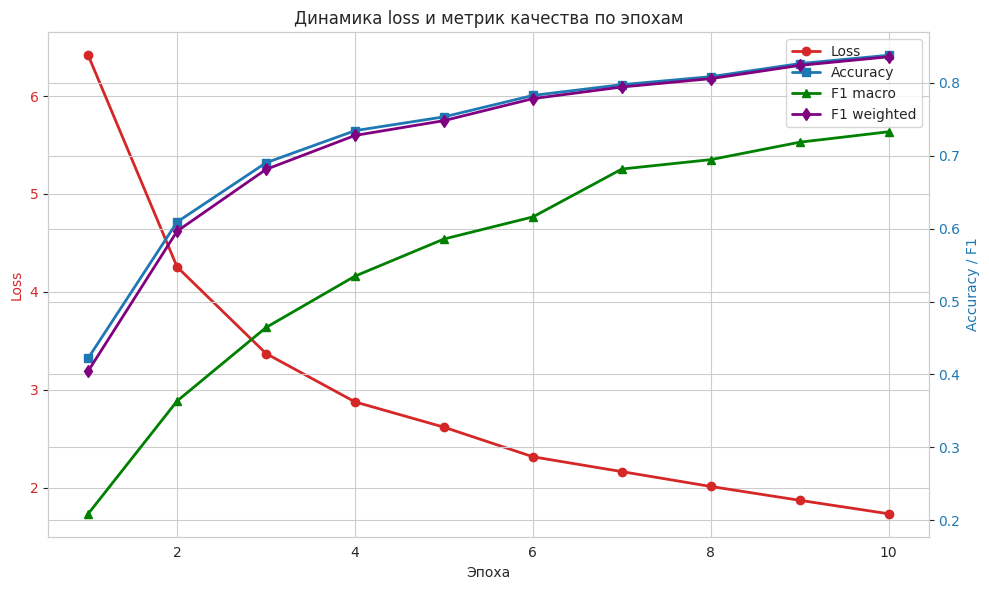

In [484]:
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

color_loss = "tab:red"
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Loss", color=color_loss)
ax1.plot(df.index, df["loss"], marker="o", color=color_loss, linewidth=2, label="Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)

ax2 = ax1.twinx()
color_metric = "tab:blue"
ax2.set_ylabel("Accuracy / F1", color=color_metric)
ax2.plot(
    df.index,
    df["accuracy"],
    marker="s",
    color=color_metric,
    linewidth=2,
    label="Accuracy",
)
ax2.plot(df.index, df["f1_macro"], marker="^", color="green", linewidth=2, label="F1 macro")
ax2.plot(
    df.index,
    df["f1_weighted"],
    marker="d",
    color="purple",
    linewidth=2,
    label="F1 weighted",
)
ax2.tick_params(axis="y", labelcolor=color_metric)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Динамика loss и метрик качества по эпохам", fontsize=12)
plt.tight_layout()
plt.show()

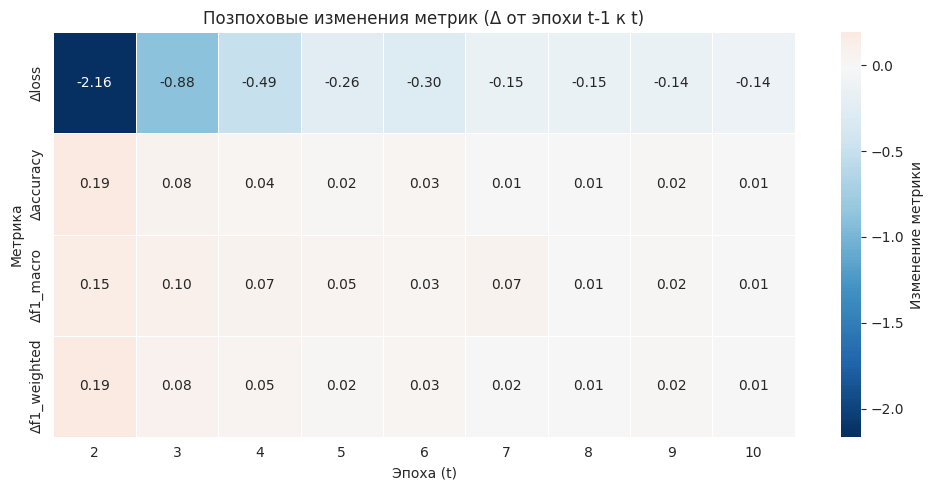

In [485]:
diff_df = df.diff().dropna()
diff_df = diff_df.rename(columns={col: f"Δ{col}" for col in diff_df.columns})

plt.figure(figsize=(10, 5))
sns.heatmap(
    diff_df.T,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Изменение метрики"},
)
plt.title("Позпоховые изменения метрик (Δ от эпохи t-1 к t)", fontsize=12)
plt.xlabel("Эпоха (t)")
plt.ylabel("Метрика")
plt.tight_layout()
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах.

In [486]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties


@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
    # функция выводит изображения в n_rows рядов и n_cols столбцов
    fig, axs = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 4, n_rows * 4),
        sharey=True,
        sharex=True,
    )

    for fig_x in axs.flatten():  # цикл повторяется (n_rows * n_cols) раз
        random_characters = int(
            np.random.uniform(0, len(dataset))
        )  # берем случайное число в диапазоне [0; len(dataset))
        im_val, label = dataset[random_characters]  # выводим изображение (тензорная форма)
        img_label = " ".join(
            map(
                lambda x: x.capitalize(),
                label_encoder.inverse_transform([label])[0].split("_"),
            )
        )  # числовую метку класса преобразуем в текстовую и немного отформатируем
        imshow(
            im_val.data.cpu(), title=img_label, plt_ax=fig_x
        )  # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

        # ниже представлен код для добавления на изображение подписи с вероятностью класса
        actual_text = "Actual : {}".format(img_label)

        font0 = FontProperties()
        font = font0.copy()

        # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
        prob_pred = (
            nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim=-1).cpu().numpy()
        )

        predicted_proba = np.max(prob_pred) * 100  # берем максимальную вероятность класса
        y_pred = np.argmax(
            prob_pred
        )  # берем числовую метку класса, для которого вероятность максимальна

        predicted_label = " ".join(
            map(
                lambda x: x.capitalize(),
                label_encoder.inverse_transform([y_pred])[0].split("_"),
            )
        )
        predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

        fig_x.add_patch(patches.Rectangle((0, 190), 7 * len(predicted_label), 25, color="white"))
        fig_x.text(
            2,
            195,
            predicted_text,
            horizontalalignment="left",
            fontproperties=font,
            verticalalignment="top",
            fontsize=8,
            color="black",
            fontweight="bold",
        )
        fig_x.set_axis_off()

    return None

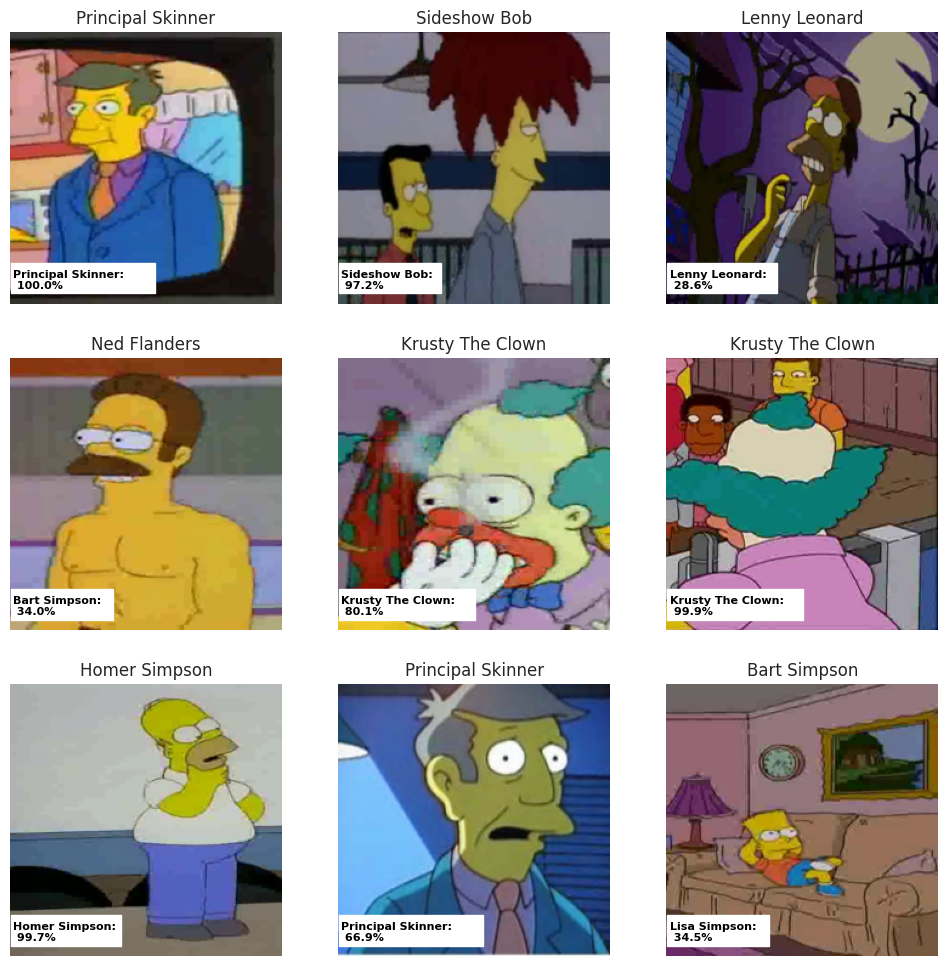

In [487]:
show_images2(n_rows=3, n_cols=3, dataset=val_dataset, model=model_simple_cnn)

In [488]:
from collections import defaultdict

import numpy as np
import pandas as pd


@torch.no_grad()
def analyze_model_errors(model, dataloader, label_encoder, device="cuda"):
    """
    Анализирует ошибки модели и возвращает статистику по каждому классу
    """
    model.eval()
    model.to(device)

    # Словари для сбора статистики
    class_stats = defaultdict(lambda: {"total": 0, "correct": 0, "errors": []})

    all_preds = []
    all_labels = []

    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Предсказания
        outputs = model(x_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        # Сохраняем для confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

        # Анализ по каждому элементу в батче
        for true_label, pred_label, prob in zip(y_batch, preds, probs):
            class_name = label_encoder.inverse_transform([true_label.cpu().numpy()])[0]
            class_name = class_name.split("_")[-1]  # берем только имя персонажа

            class_stats[class_name]["total"] += 1

            if true_label == pred_label:
                class_stats[class_name]["correct"] += 1
            else:
                pred_class_name = label_encoder.inverse_transform([pred_label.cpu().numpy()])[0]
                pred_class_name = pred_class_name.split("_")[-1]
                class_stats[class_name]["errors"].append(
                    {
                        "predicted": pred_class_name,
                        "confidence": prob[pred_label].item(),
                    }
                )

    # Создаем DataFrame с результатами
    results = []
    for class_name, stats in class_stats.items():
        total = stats["total"]
        correct = stats["correct"]
        error_count = total - correct
        error_rate = (error_count / total) * 100 if total > 0 else 0

        results.append(
            {
                "class": class_name,
                "total": total,
                "correct": correct,
                "errors": error_count,
                "error_rate": error_rate,
            }
        )

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values("error_rate", ascending=False)

    return df_results, all_preds, all_labels, class_stats


# Запуск анализа
df_errors, all_preds, all_labels, class_stats = analyze_model_errors(
    model_simple_cnn,
    val_loader,  # или val_loader
    label_encoder,
    DEVICE,
)

print("=" * 60)
print("СТАТИСТИКА ОШИБОК ПО КЛАССАМ")
print("=" * 60)
print(df_errors.to_string(index=False))

СТАТИСТИКА ОШИБОК ПО КЛАССАМ
             class  total  correct  errors  error_rate
              hutz      1        0       1  100.000000
               stu      2        0       2  100.000000
          jailbird     14        2      12   85.714286
            hoover      4        1       3   75.000000
               gil      7        3       4   57.142857
             frink     16        7       9   56.250000
              mann      8        4       4   50.000000
          spuckler     12        6       6   50.000000
            willie     30       17      13   43.333333
            gumble     26       15      11   42.307692
        wolfcastle     11        7       4   36.363636
               mel     10        7       3   30.000000
           bouvier     44       31      13   29.545455
              tony      7        5       2   28.571429
            quimby     61       46      15   24.590164
            prince     18       14       4   22.222222
          smithers     45       35  

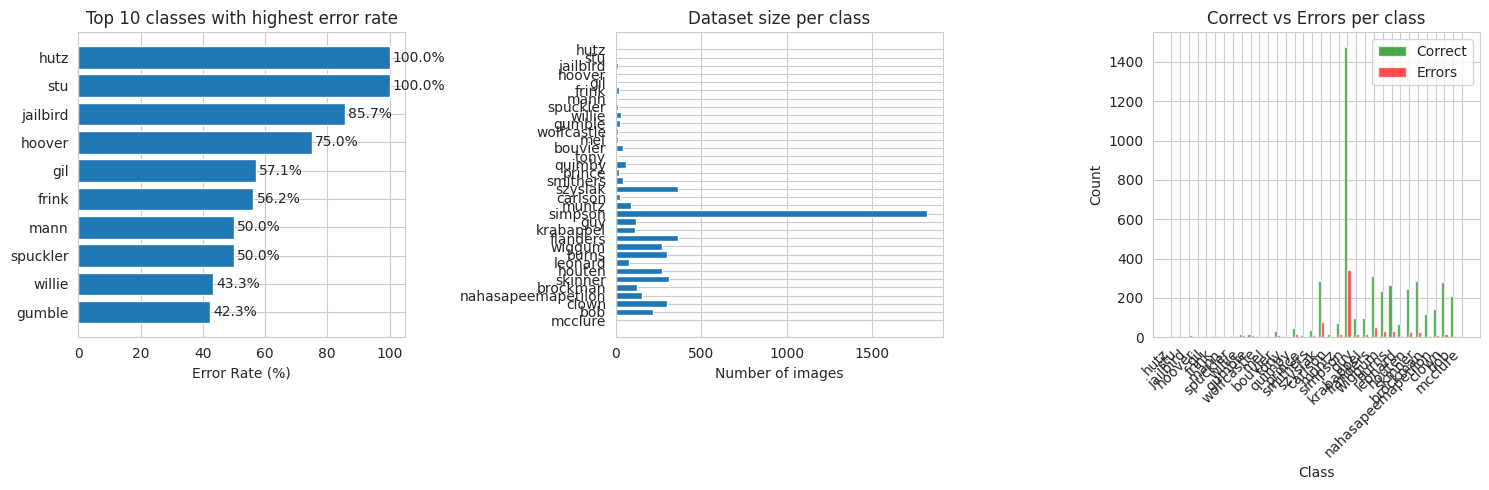

In [489]:
def plot_error_analysis(df_results, top_n=10):
    """
    Визуализирует ошибки модели
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # График 1: Топ классов с наибольшим количеством ошибок
    top_errors = df_results.nlargest(top_n, "error_rate")

    axes[0].barh(range(len(top_errors)), top_errors["error_rate"].values)
    axes[0].set_yticks(range(len(top_errors)))
    axes[0].set_yticklabels(top_errors["class"].values)
    axes[0].set_xlabel("Error Rate (%)")
    axes[0].set_title(f"Top {top_n} classes with highest error rate")
    axes[0].invert_yaxis()

    # Добавляем значения на бары
    for i, (idx, row) in enumerate(top_errors.iterrows()):
        axes[0].text(row["error_rate"] + 1, i, f"{row['error_rate']:.1f}%", va="center")

    # График 2: Распределение количества изображений по классам
    axes[1].barh(range(len(df_results)), df_results["total"].values)
    axes[1].set_yticks(range(len(df_results)))
    axes[1].set_yticklabels(df_results["class"].values)
    axes[1].set_xlabel("Number of images")
    axes[1].set_title("Dataset size per class")
    axes[1].invert_yaxis()

    # График 3: Соотношение correct/errors
    x = np.arange(len(df_results))
    width = 0.35

    axes[2].bar(
        x - width / 2,
        df_results["correct"],
        width,
        label="Correct",
        color="green",
        alpha=0.7,
    )
    axes[2].bar(
        x + width / 2,
        df_results["errors"],
        width,
        label="Errors",
        color="red",
        alpha=0.7,
    )
    axes[2].set_xlabel("Class")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Correct vs Errors per class")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(df_results["class"], rotation=45, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# Запуск визуализации
plot_error_analysis(df_errors)

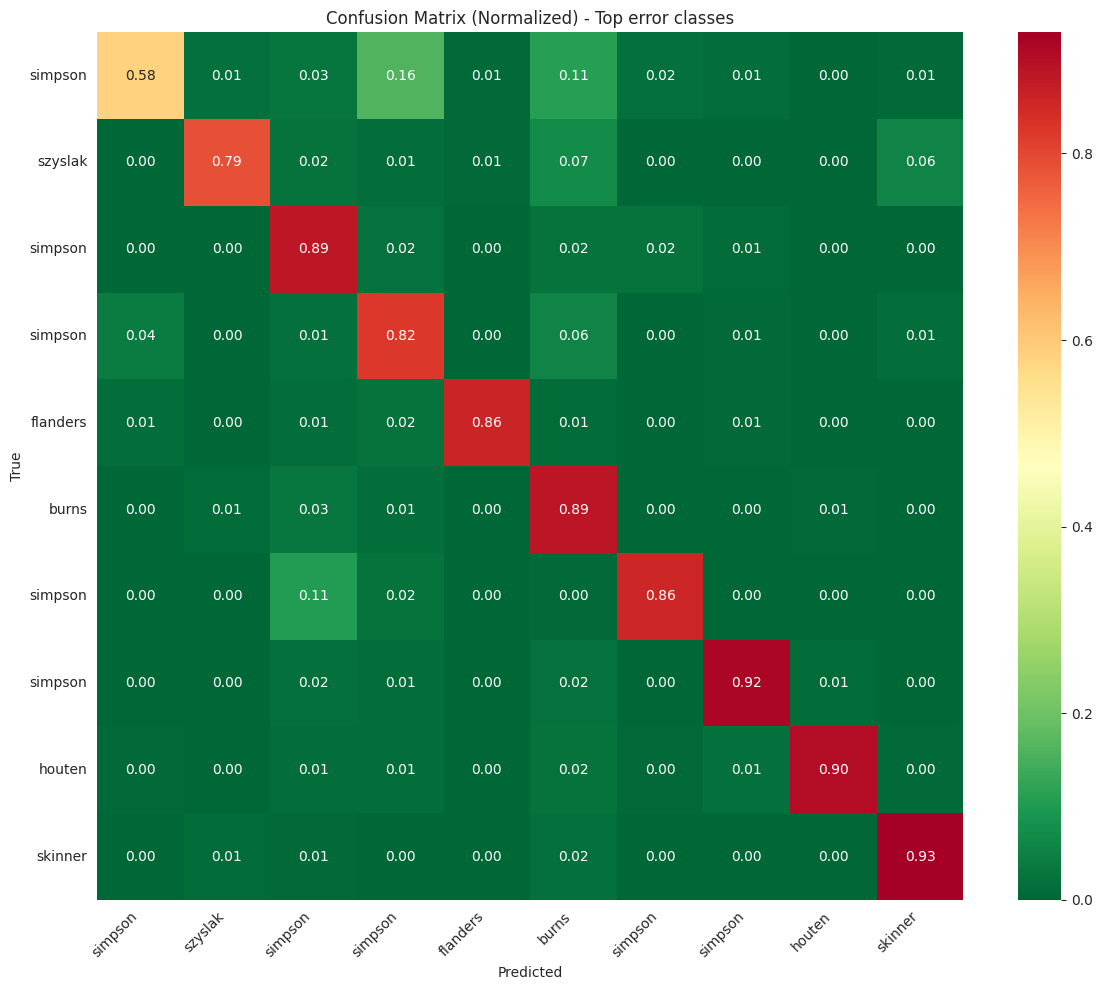

In [490]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(all_preds, all_labels, label_encoder, top_n=15):
    """
    Строит confusion matrix для самых частых классов
    """
    # Получаем имена классов
    class_names = [
        label_encoder.inverse_transform([i])[0].split("_")[-1]
        for i in range(len(label_encoder.classes_))
    ]

    # Строим confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Нормализуем по строкам (чтобы видеть долю ошибок)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # Находим классы с наибольшим количеством ошибок
    error_counts = cm.sum(axis=1) - np.diag(cm)
    top_error_classes = np.argsort(error_counts)[-top_n:][::-1]

    # Отображаем только топ классов по ошибкам
    cm_filtered = cm_normalized[top_error_classes][:, top_error_classes]
    labels_filtered = [class_names[i] for i in top_error_classes]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_filtered,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        xticklabels=labels_filtered,
        yticklabels=labels_filtered,
    )
    plt.title("Confusion Matrix (Normalized) - Top error classes")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Запуск
plot_confusion_matrix(all_preds, all_labels, label_encoder, top_n=10)

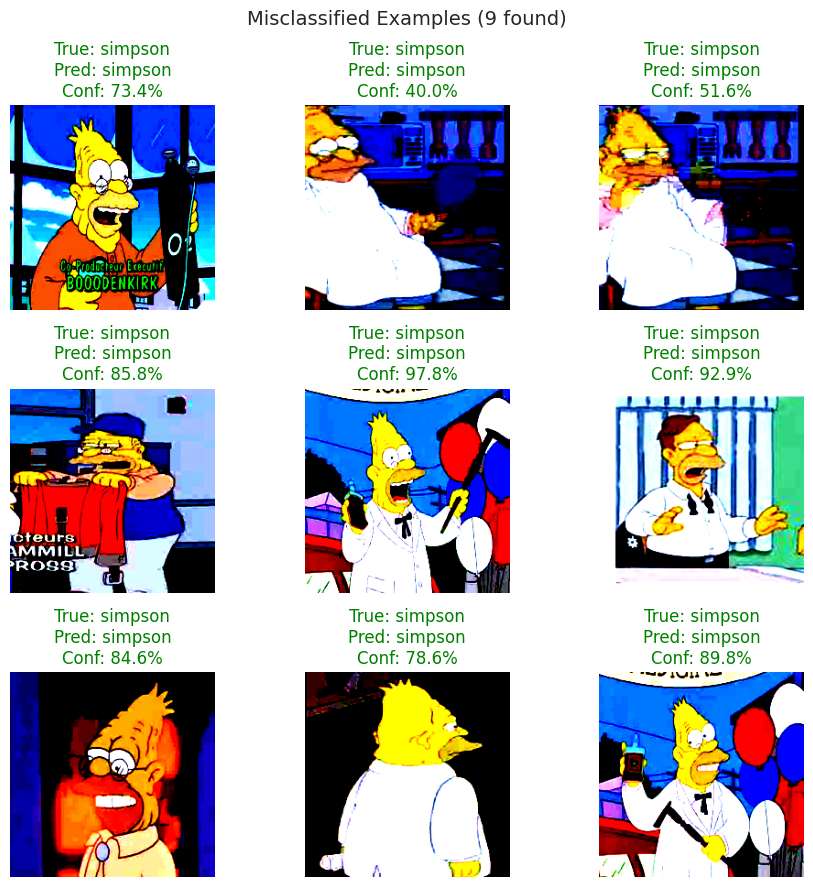

In [491]:
@torch.no_grad()
def show_misclassified_examples(model, dataset, label_encoder, num_examples=9, device="cuda"):
    """
    Показывает примеры, где модель ошиблась
    """
    model.eval()
    model.to(device)

    misclassified = []

    # Собираем ошибочные предсказания
    for idx in range(len(dataset)):
        if len(misclassified) >= num_examples:
            break

        img, label = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)

        output = model(img_tensor)
        pred = output.argmax(dim=1).item()

        if pred != label:
            prob = torch.softmax(output, dim=1)[0][pred].item()

            true_label = label_encoder.inverse_transform([label])[0].split("_")[-1]
            pred_label = label_encoder.inverse_transform([pred])[0].split("_")[-1]

            misclassified.append(
                {
                    "image": img,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "confidence": prob * 100,
                    "idx": idx,
                }
            )

    # Отображаем ошибки
    n_cols = min(3, num_examples)
    n_rows = (len(misclassified) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for i, example in enumerate(misclassified):
        if i >= len(axes):
            break

        ax = axes[i]
        img = example["image"].permute(1, 2, 0).numpy()
        # Денормализация, если была нормализация
        # img = img * std + mean

        ax.imshow(img)
        ax.set_title(
            f"True: {example['true_label']}\nPred: {example['pred_label']}\nConf: {example['confidence']:.1f}%",
            color="red" if example["true_label"] != example["pred_label"] else "green",
        )
        ax.axis("off")

    # Скрываем лишние подграфики
    for i in range(len(misclassified), len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"Misclassified Examples ({len(misclassified)} found)", fontsize=14)
    plt.tight_layout()
    plt.show()

    return misclassified


# Запуск
misclassified_examples = show_misclassified_examples(
    model_simple_cnn,
    val_dataset,  # или test_dataset
    label_encoder,
    num_examples=9,
    device=DEVICE,
)

## Шаг 6. Submit на Kaggle

Создадим loader для тестовых данных

In [492]:
test_dataset = SimpsonsDataset(test_files, label_encoder=label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [493]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

Получем предсказание меток классов для тестовых данных:

In [494]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

и преобразуем их в текстовые метки:

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle (проверьте путь, по которому у вас лежит файл sample_submission.csv и при необходимости скорректируйте путь в коде ниже):

In [496]:
import pandas as pd

sample_submission = pd.read_csv("sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [497]:
my_submission = pd.DataFrame(
    {"Id": [path.name for path in test_files], "Expected": predicted_text_labels}
)
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [498]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут)

In [499]:
my_submission.to_csv("simple_cnn_baseline.csv", index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся score нас явно не устраивает. Надо с этим что-то сделать.

Вам предлагается творческая и исследовательская свобода в том, как вы будете улучшать score модели. Вот некоторые направления, которые вы, возможно, захотите попробовать:
1. Работа с датасетом:
* Попробуйте увеличить разнообразие обучающей выборки при помощи аугментации ([ссылка 1](https://habr.com/ru/companies/smartengines/articles/264677/), [ссылка 2](https://www.geeksforgeeks.org/python-data-augmentation/));
* Используя результаты функции eval_one_epoch, вы можете посмотреть, как метрика f1-score внутри класса связана с размером самого класса в обучающей выборке. Скорее всего, вы заметите прямую зависимость. Решением может быть увеличение размеров слабо представленных классов. Сделать это можно, вручную добавив этот функционал в SimpsonsDataset или воспользовавшись инструментом WeightedRandomSampler.

* Также вы можете изучить, какие изображения модель классифицирует неверно. Можно просто посмотреть неверно классифицированные изображения в валидационном датасете. Можно попробовать более фундаментальный подход - создать dataloader из всех изображений обучающей и валидационной выборки в SimpsonsDataset c режимом 'val', прогнать данные через обученную модель simple_cnn. Более того, можно обучить несколько моделей с разной архитектурой, и прогнать объединенный датасет через все эти модели - и выделить те изображения, в классификации которых ошиблись несколько моделей.

* Это поможет понять, как качество и чистота исходных данных влияет на результаты обучения модели. Если вы обнаружите ошибки в simpsons_dataset и решите их исправить или удалить некоторые изображения из обучающей выборки - сделайте это в ноутбуке, чтобы при проверке можно было повторить результаты работы вашего кода.  

2. Работа с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных и полносвязных слоёв;
* А еще есть где пулинги и батч-норм!

3. Применение техник, описанных в предыдущих пунктах, позволяет добиться довольно высоких результатов. Но вы можете попробовать файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

4. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

5. Наконец, возможно, стоит подумать об ансамблях


Надеюсь, что у Вас получится!